# EDA — Chotot Real Estate Dataset

Khám phá dữ liệu bất động sản sau bước Parse & Clean.  
Input: `../data/chotot_final.csv`

**Mục tiêu:**
- Hiểu phân phối của các feature chính
- Phát hiện outlier còn sót lại
- Xem mối quan hệ giữa các feature với giá
- Cung cấp insight cho bước Preprocessing & Modeling


In [6]:
!pip install seaborn
!pip install jinja2


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Hiển thị đầy đủ cột
pd.set_option("display.max_columns", None)

INPUT_PATH = Path("../data/chotot_final.csv")
df = pd.read_csv(INPUT_PATH)

print("Shape:", df.shape)
df.head(3)

Shape: (6969, 29)


,title,area,Diện tích đất:,Hướng cửa chính:,Giấy tờ pháp lý:,Đặc điểm nhà/đất:,Loại hình đất:,Chiều ngang:,Chiều dài:,Số phòng ngủ:,Số phòng vệ sinh:,Loại hình nhà ở:,Tình trạng nội thất:,Diện tích sử dụng:,Tình trạng bất động sản:,Diện tích:,Loại hình căn hộ:,Tổng số tầng:,Tầng số:,Hướng ban công:,Đặc điểm căn hộ:,Loại hình văn phòng:,street,ward,district,city,Phân khu/Lô/Block/Tháp,has_floor_number,Price (trieu VND)
0,Tôi bán nhà xây mới 100% 4 lầu tặng nội thất 1%MG,36.3,36.3,Nam,Đã có sổ,Mặt tiền,Đất nông nghiệp,4.7,7.5,3.0,4.0,"Nhà ngõ, hẻm",Nội thất cao cấp,140.0,Đã bàn giao,67.0,Chung cư,4.0,-1.0,Unknown,Unknown,Unknown,đường lê quang định,phường 11,quận bình thạnh,tp hồ chí minh,Không thuộc project/block,0,5500.0
1,BÁN NỀN KHU DÂN CƯ MINH THẮNG,115.0,115.0,Đông Bắc,Đã có sổ,Mặt tiền,Đất thổ cư,6.0,19.0,3.0,4.0,"Nhà ngõ, hẻm",Nội thất cao cấp,140.0,Đã bàn giao,67.0,Chung cư,4.0,-1.0,Unknown,Unknown,Unknown,khu dân cư minh thắng - cà mau,phường 9,thành phố cà mau,cà mau,Không thuộc project/block,0,1570.0
2,Đất nền giá đầu tư becamex,250.0,250.0,Đông Bắc,Đã có sổ,Mặt tiền,Đất thổ cư,10.0,25.0,3.0,4.0,"Nhà ngõ, hẻm",Nội thất cao cấp,140.0,Đã bàn giao,67.0,Chung cư,4.0,-1.0,Unknown,Unknown,Unknown,ql13,thị trấn lai uyên,huyện bàu bàng,bình dương,Không thuộc project/block,0,580.0


## 2. Tổng quan Dataset

### 2.1 Thông tin cột & kiểu dữ liệu

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6969 entries, 0 to 6968
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   title                     6969 non-null   str    
 1   area                      6607 non-null   float64
 2   Diện tích đất:            6969 non-null   float64
 3   Hướng cửa chính:          6969 non-null   str    
 4   Giấy tờ pháp lý:          6969 non-null   str    
 5   Đặc điểm nhà/đất:         6969 non-null   str    
 6   Loại hình đất:            6969 non-null   str    
 7   Chiều ngang:              6969 non-null   float64
 8   Chiều dài:                6969 non-null   float64
 9   Số phòng ngủ:             6969 non-null   float64
 10  Số phòng vệ sinh:         6969 non-null   float64
 11  Loại hình nhà ở:          6969 non-null   str    
 12  Tình trạng nội thất:      6969 non-null   str    
 13  Diện tích sử dụng:        6969 non-null   float64
 14  Tình trạng bất động

### 2.2 Thống kê mô tả các cột numeric

In [9]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe().T.style.background_gradient(cmap="Blues", axis=1)

,count,mean,std,min,25%,50%,75%,max
area,6607.000000,188.285282,556.093323,20.000000,49.000000,70.000000,107.500000,7408.000000
Diện tích đất:,6969.000000,304.658475,5512.011219,11.000000,48.000000,74.000000,115.000000,450000.000000
Chiều ngang:,6969.000000,18.609650,512.533305,1.000000,4.000000,5.000000,6.000000,30000.000000
Chiều dài:,6969.000000,41.602202,814.046082,1.000000,12.000000,17.000000,22.000000,45000.000000
Số phòng ngủ:,6969.000000,3.030994,1.498435,1.000000,2.000000,3.000000,4.000000,10.000000
Số phòng vệ sinh:,6969.000000,2.680155,1.310454,1.000000,2.000000,2.000000,3.000000,6.000000
Diện tích sử dụng:,6969.000000,210.597307,5081.286716,3.000000,59.000000,93.000000,160.000000,300000.000000
Diện tích:,6969.000000,254.648231,2667.560496,1.000000,51.000000,65.000000,79.000000,66664.000000
Tổng số tầng:,6969.000000,2.772708,1.415835,1.000000,2.000000,3.000000,4.000000,10.000000
Tầng số:,6969.000000,10.176352,7.337899,-1.000000,3.000000,9.000000,15.000000,36.000000


- Cột count cho ta biết số lượng dữ liệu hợp lệ.
- mean cho ta biết giá trị trung bình
- std (standard deviation) cho ta biết độ phân tán dữ liệu (nếu std lớn thì giá nhà biến động mạnh)
- min và max để phát hiện outlier.
- 25%, 50%, 75% là median.


Nhận xét: Phân này giúp chúng ta phát hiện và xử lý outlier trước khi modeling
- Feature "Diện tích đất" chứa nhiều giá trị ngoại lệ rất lớn so với phần lớn dữ liệu.
- Feature "chiều ngang" có max là 30000m => đây là đất chắc chắn không phải nhà.
- Feature "chiều dài" có max là 45000m => đây là đất chắn chắn không phải nhà.

Qua thống kê mô tả, dataset chứa nhiều giá trị ngoại lệ và phân phối lệch phải mạnh, đặc biệt ở các feature liên quan đến diện tích và giá bán. Ngoài ra, một số feature có khả năng mang thông tin tương đồng, cần xem xét trong bước preprocessing và modelin

### 2.3 Missing values

,missing_count,missing_percent
area,362,5.19


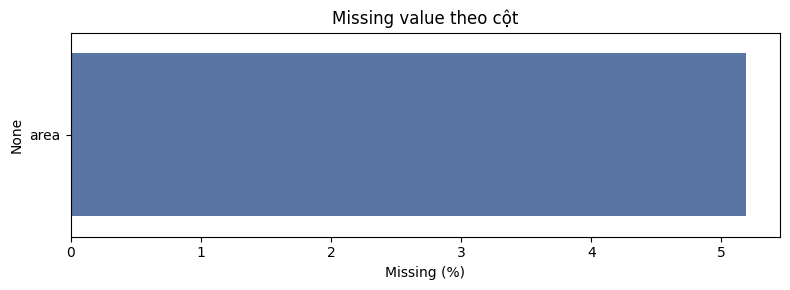

In [10]:
missing = pd.DataFrame({
    "missing_count":   df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("missing_percent", ascending=False)

missing = missing[missing["missing_count"] > 0]

if missing.empty:
    print("Không còn missing value.")
else:
    display(missing)

    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    sns.barplot(x="missing_percent", y=missing.index, data=missing, ax=ax, color="#4C72B0")
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing value theo cột")
    plt.tight_layout()
    plt.show()

Các giá trị missing đã được xử lý ở bước Parse dữ liệu rồi.

### 2.4 Giá trị unique các cột categorical

In [11]:
cat_cols = df.select_dtypes(include="object").columns.tolist()

unique_df = pd.DataFrame({
    "unique_count": df[cat_cols].nunique(),
    "unique_ratio":  (df[cat_cols].nunique() / len(df) * 100).round(2)
}).sort_values("unique_count", ascending=False)

display(unique_df)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\1898610368.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


,unique_count,unique_ratio
title,6953,99.77
street,2865,41.11
ward,986,14.15
district,255,3.66
Phân khu/Lô/Block/Tháp,96,1.38
city,68,0.98
Hướng ban công:,9,0.13
Hướng cửa chính:,8,0.11
Loại hình căn hộ:,6,0.09
Loại hình đất:,4,0.06


Nhận xét: Chúng ta phát hiện ra feature "tittle", "street", "ward" bị unique nặng. Không thể đưa vào one-hot trược tiếp.
Nên drops nếu không đóng góp gì nhiều vào giá nhà.

## 3. Phân phối biến mục tiêu — `Price (trieu VND)`

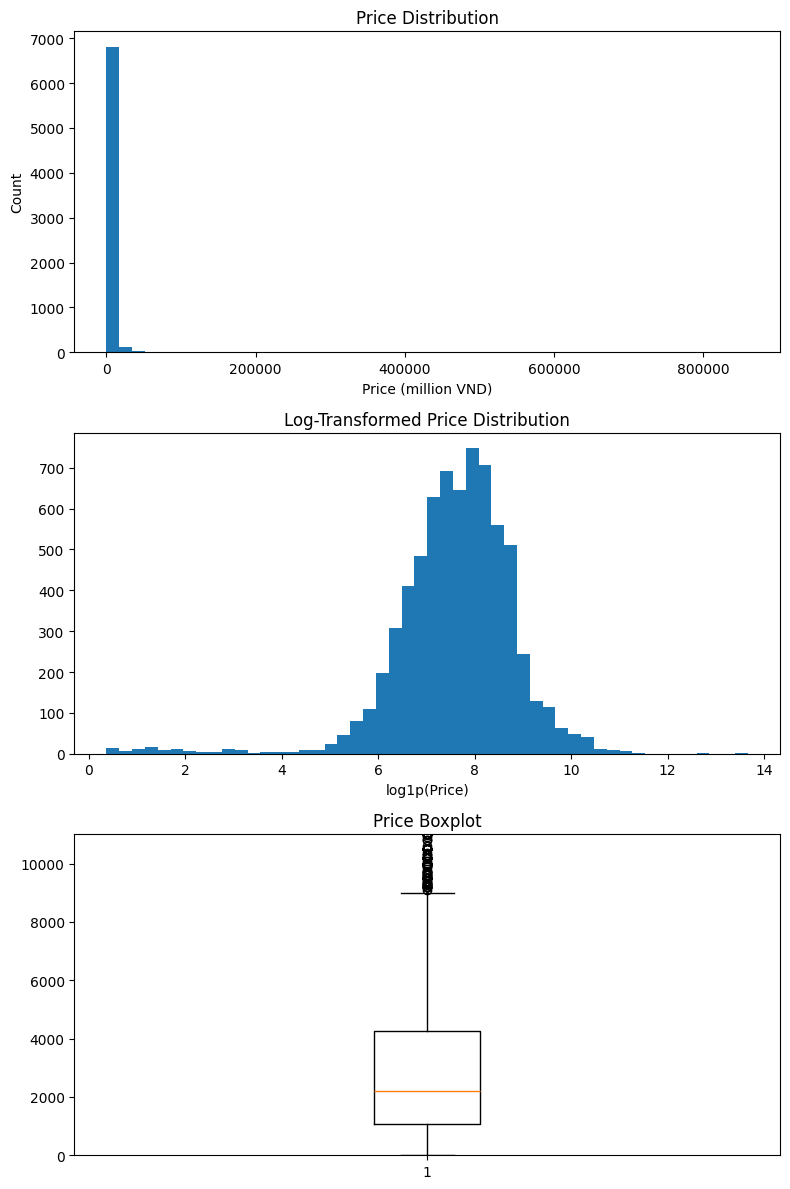

Mean   : 3,825.81
Median : 2,200.00
Std    : 12,976.57
Skew   : 47.23


In [12]:
TARGET = "Price (trieu VND)"

price = df[TARGET].dropna()

fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# Histogram giá gốc
axes[0].hist(price, bins=50)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (million VND)")
axes[0].set_ylabel("Count")

# Histogram sau log transform
axes[1].hist(np.log1p(price), bins=50)
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("log1p(Price)")

# Boxplot
axes[2].boxplot(price)
axes[2].set_title("Price Boxplot")

# Giới hạn để dễ nhìn
axes[2].set_ylim(0, price.quantile(0.95))

plt.tight_layout()
plt.show()

# Thống kê
print(f"Mean   : {price.mean():,.2f}")
print(f"Median : {price.median():,.2f}")
print(f"Std    : {price.std():,.2f}")
print(f"Skew   : {price.skew():,.2f}")

Nhận xét: Chart Price distribution thể hiện gần như toàn cột đều dồn sát bên trái và phần bên phải trống rất dài.
Nếu này có nghĩa là dataset bị skew phải lớn.
- Đa số nhà giá thấp - trung bình
- Một số rất ít nhà giá cực cao.

## 4. Phân phối các Numeric Features

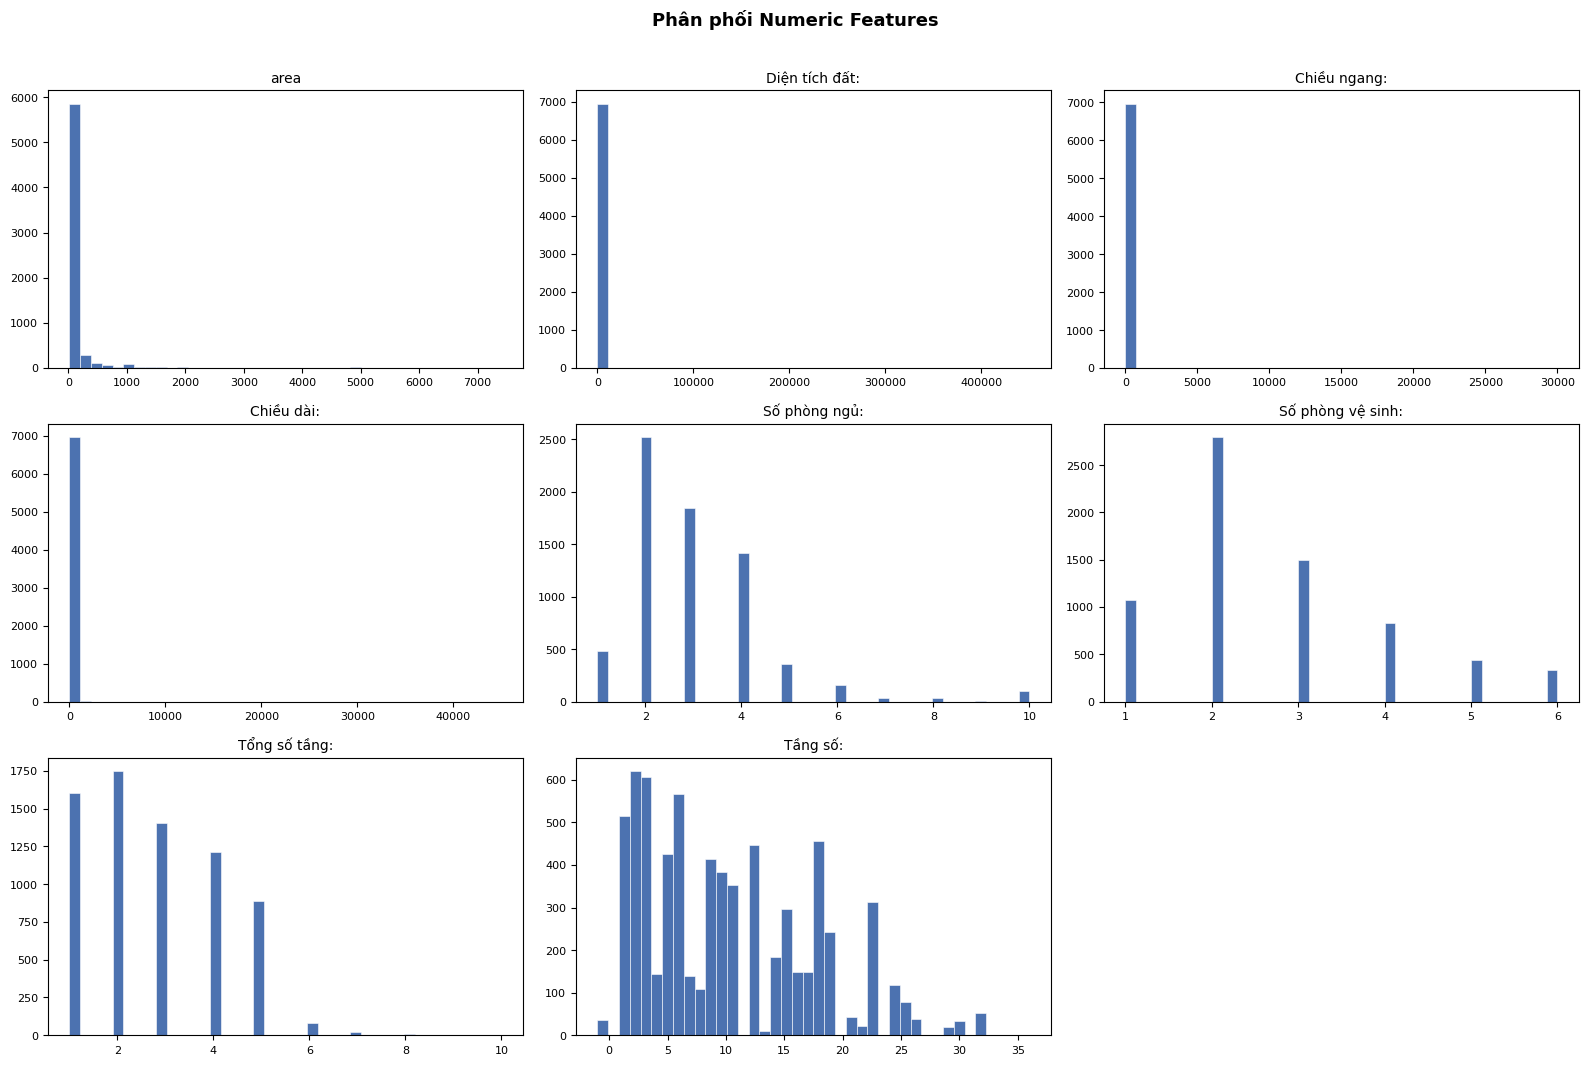

In [13]:
# Các cột numeric quan trọng (bỏ target)
num_features = [
    "area", "Diện tích đất:", "Chiều ngang:", "Chiều dài:",
    "Số phòng ngủ:", "Số phòng vệ sinh:", "Tổng số tầng:", "Tầng số:"
]
num_features = [c for c in num_features if c in df.columns]

n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color="#4C72B0", edgecolor="white", linewidth=0.4)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].tick_params(labelsize=8)

# Ẩn axes dư
for j in range(len(num_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Phân phối Numeric Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

1. Nhóm diện tích (area, diện tích đất, chiều ngang, chiều dài)
- Lệch phải rất mạnh
- Có đuôi dài
- Xuất hiện outlier cực lớn
2. Số phòng ngủ có dữ liệu khá đẹp
3. Số phòng vệ sinh có dữ liệu khá đẹp
4. Tổng số tàng dữ liệu tương đôi.
5. Tầng số thể hiện nhiều căn hộ chung cư tập trung ở các tầng phổ biến


Các feature numeric trong dataset có sự khác biệt rõ rệt về phân phối. Nhóm feature liên quan đến diện tích có phân phối lệch phải mạnh và chứa nhiều giá trị ngoại lệ lớn, cho thấy sự tồn tại của extreme values hoặc dữ liệu bất thường. Trong khi đó, các feature như số phòng ngủ, số phòng vệ sinh và tổng số tầng có phân phối ổn định hơn và phản ánh đúng đặc điểm phổ biến của bất động sản dân cư.

## 5. Outlier Analysis

### 5.1 Boxplot các cột numeric chính

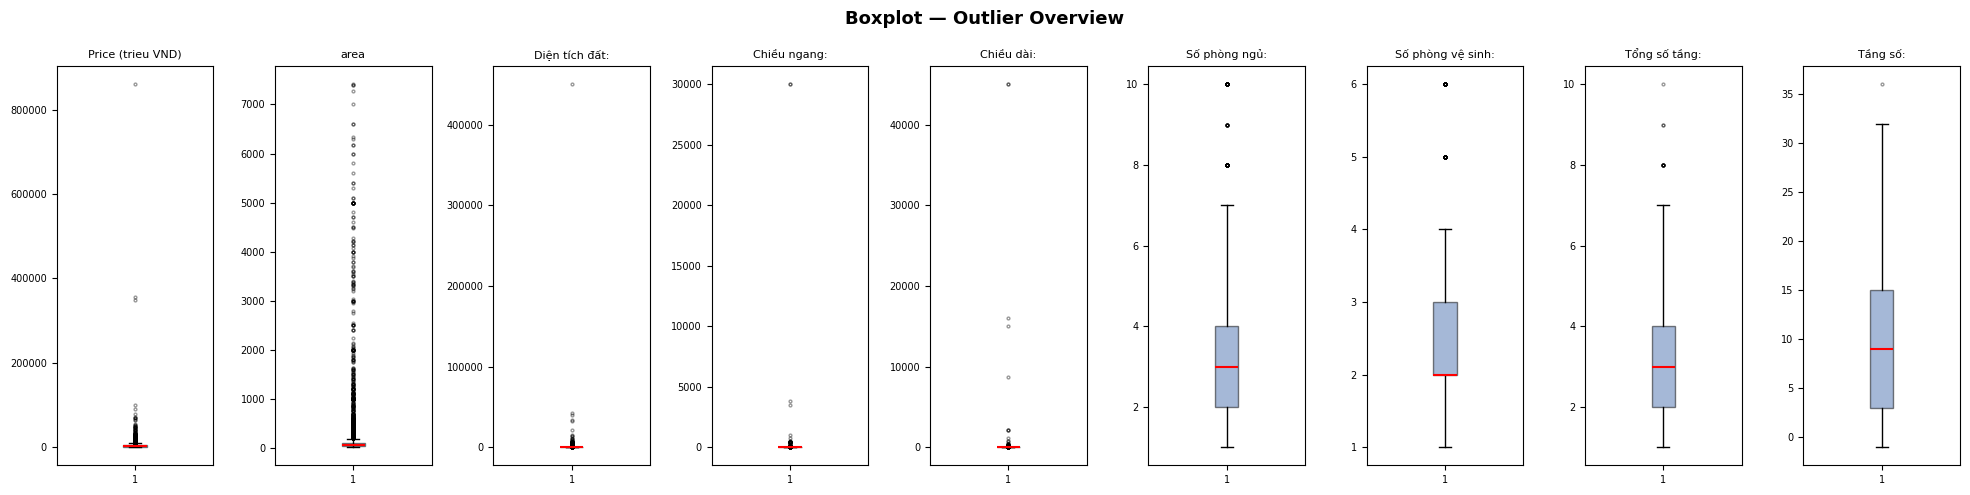

In [14]:
outlier_cols = [TARGET] + [c for c in num_features if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(max(14, len(outlier_cols) * 2.2), 5))
if len(outlier_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, outlier_cols):
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.5),
               medianprops=dict(color="red", linewidth=1.5),
               flierprops=dict(marker="o", markersize=2, alpha=0.4, color="gray"))
    ax.set_title(col[:20], fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Boxplot — Outlier Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Ta có thể thấy 4 feature đầu có outlier cực nặng. Cần phải được xử lý.

### 5.2 IQR Outlier count per column

In [15]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    mask = (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)
    return mask.sum()

outlier_summary = pd.DataFrame({
    "outlier_count":   {c: iqr_outlier_count(df[c].dropna()) for c in outlier_cols},
    "outlier_percent": {c: round(iqr_outlier_count(df[c].dropna()) / df[c].notna().sum() * 100, 2)
                        for c in outlier_cols}
}).sort_values("outlier_percent", ascending=False)

display(outlier_summary)

,outlier_count,outlier_percent
Chiều ngang:,1038,14.89
area,827,12.52
Diện tích đất:,858,12.31
Số phòng vệ sinh:,772,11.08
Chiều dài:,638,9.15
Price (trieu VND),443,6.36
Số phòng ngủ:,149,2.14
Tổng số tầng:,11,0.16
Tầng số:,1,0.01


> **Nhận xét:**

> — Cột nào có outlier % cao → cân nhắc filter thêm ở Preprocessing.  
> — Giá (Price) thường skew phải mạnh → nên log-transform trước khi đưa vào model.

## 6. Phân phối Categorical Features

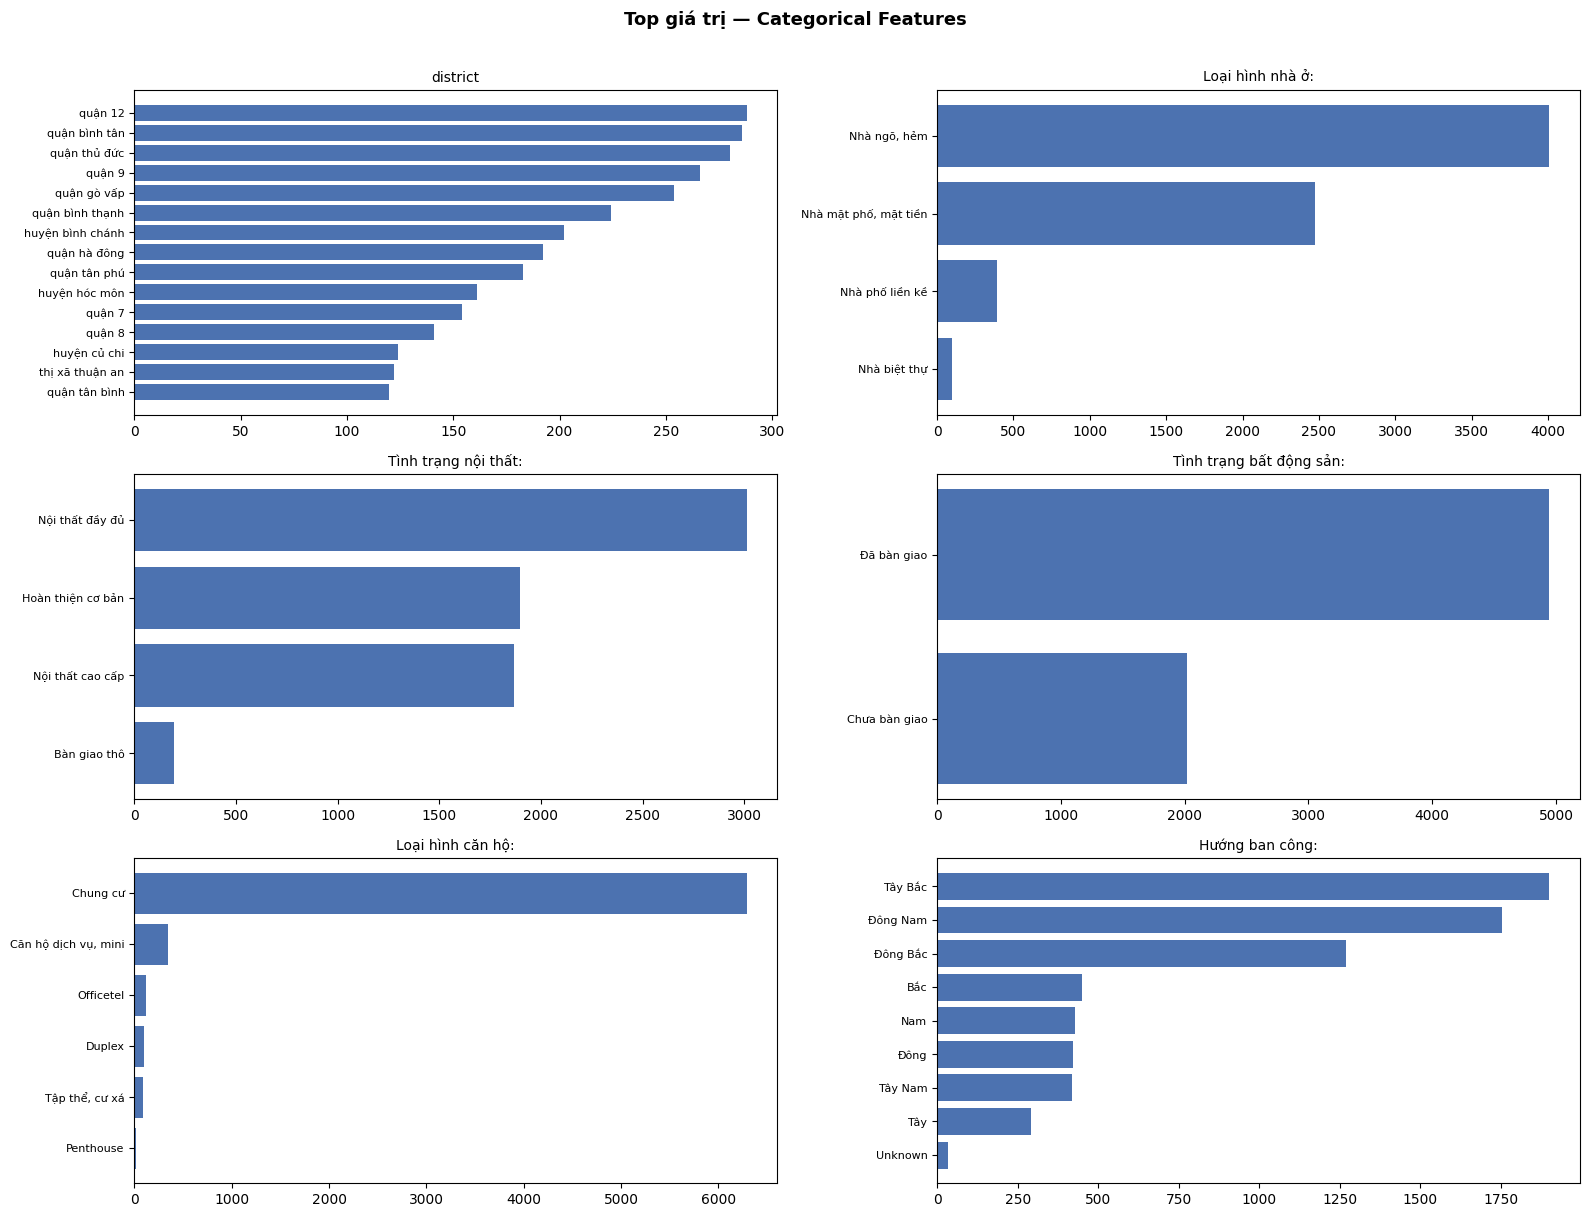

In [16]:
cat_plot_cols = [
    "district", "Loại hình nhà ở:", "Tình trạng nội thất:",
    "Tình trạng bất động sản:", "Loại hình căn hộ:", "Hướng ban công:"
]
cat_plot_cols = [c for c in cat_plot_cols if c in df.columns]

n_cols = 2
n_rows = (len(cat_plot_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_plot_cols):
    vc = df[col].value_counts().head(15)
    axes[i].barh(vc.index[::-1], vc.values[::-1], color="#4C72B0")
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis="y", labelsize=8)

for j in range(len(cat_plot_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top giá trị — Categorical Features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. Giá vs các Feature chính

### 7.1 Price vs Area (scatter)

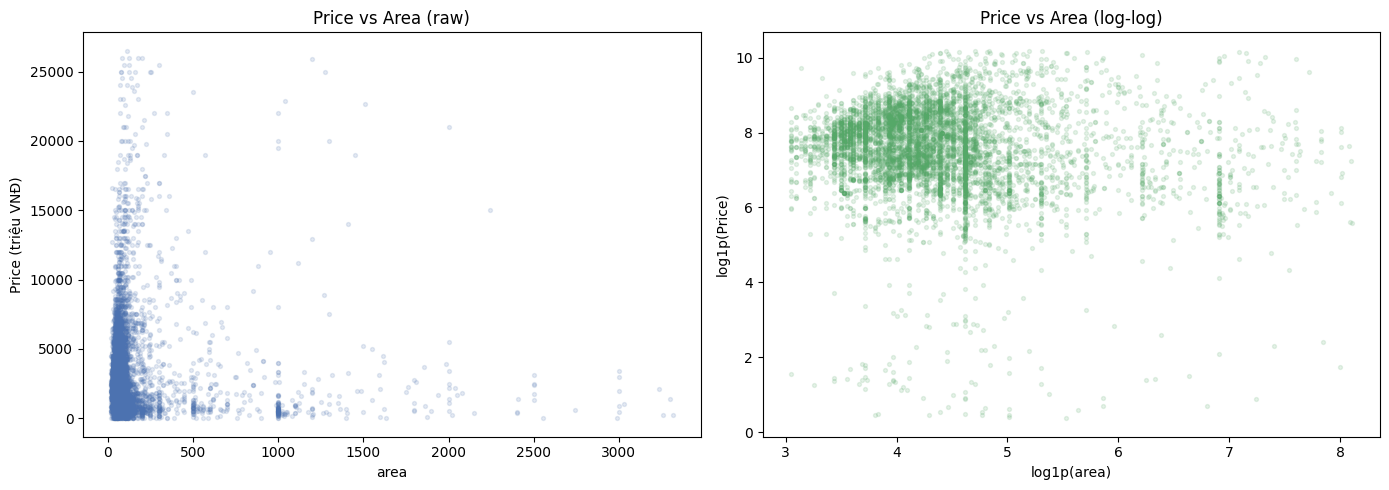

In [17]:
area_col = "area" if "area" in df.columns else "Diện tích đất:"
plot_df  = df[[TARGET, area_col]].dropna()
plot_df  = plot_df[
    (plot_df[TARGET] > 0) &
    (plot_df[area_col] > 0) &
    (plot_df[TARGET]   < plot_df[TARGET].quantile(0.99)) &
    (plot_df[area_col] < plot_df[area_col].quantile(0.99))
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(plot_df[area_col], plot_df[TARGET], alpha=0.15, s=8, color="#4C72B0")
axes[0].set_xlabel(area_col)
axes[0].set_ylabel("Price (triệu VNĐ)")
axes[0].set_title("Price vs Area (raw)")

axes[1].scatter(np.log1p(plot_df[area_col]), np.log1p(plot_df[TARGET]),
                alpha=0.15, s=8, color="#55A868")
axes[1].set_xlabel(f"log1p({area_col})")
axes[1].set_ylabel("log1p(Price)")
axes[1].set_title("Price vs Area (log-log)")

plt.tight_layout()
plt.show()

### 7.2 Giá trung bình theo District (top 20)

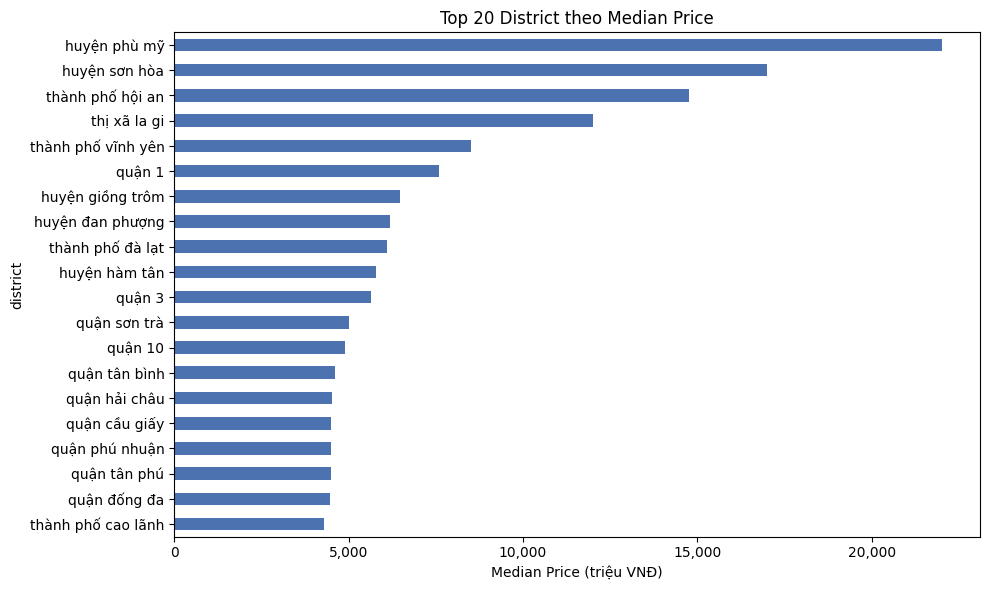

In [18]:
if "district" in df.columns:
    district_price = (
        df.groupby("district")[TARGET]
        .median()
        .sort_values(ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    district_price[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
    ax.set_xlabel("Median Price (triệu VNĐ)")
    ax.set_title("Top 20 District theo Median Price")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()

### 7.3 Price theo Loại hình nhà ở (boxplot)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3273513380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=loai_col, y=TARGET, order=order,
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3273513380.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)


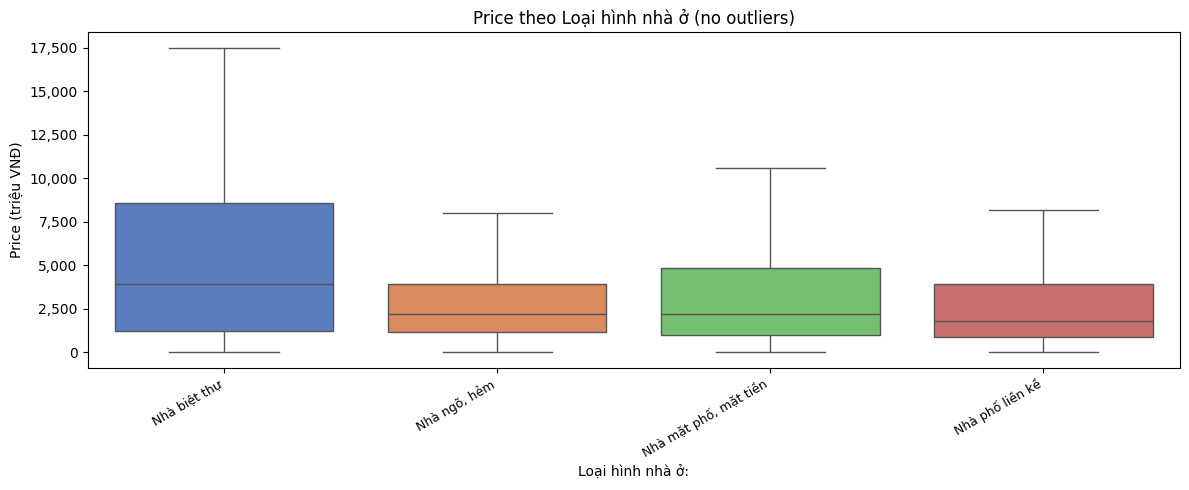

In [19]:
loai_col = "Loại hình nhà ở:"
if loai_col in df.columns:
    order = (df.groupby(loai_col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(data=df, x=loai_col, y=TARGET, order=order,
                showfliers=False, palette="muted", ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Price (triệu VNĐ)")
    ax.set_title("Price theo Loại hình nhà ở (no outliers)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()

### 7.4 Price theo số phòng ngủ & số tầng

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3719920869.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[col].isin(order)], x=col, y=TARGET,
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3719920869.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df[col].isin(order)], x=col, y=TARGET,


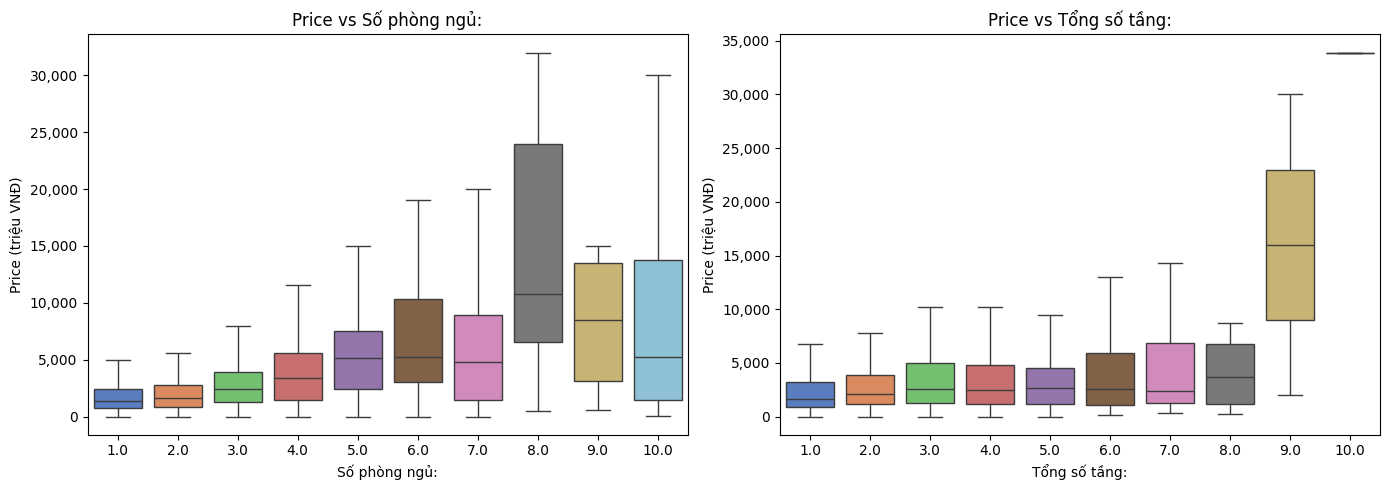

In [20]:
count_cols = ["Số phòng ngủ:", "Tổng số tầng:"]
count_cols = [c for c in count_cols if c in df.columns]

if count_cols:
    fig, axes = plt.subplots(1, len(count_cols), figsize=(14, 5))
    if len(count_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, count_cols):
        order = sorted(df[col].dropna().unique())
        order = [v for v in order if v >= 0][:12]  # bỏ -1 (N/A), cap ở 12
        sns.boxplot(data=df[df[col].isin(order)], x=col, y=TARGET,
                    order=order, showfliers=False, palette="muted", ax=ax)
        ax.set_title(f"Price vs {col}")
        ax.set_ylabel("Price (triệu VNĐ)")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

    plt.tight_layout()
    plt.show()

## 8. Correlation Heatmap

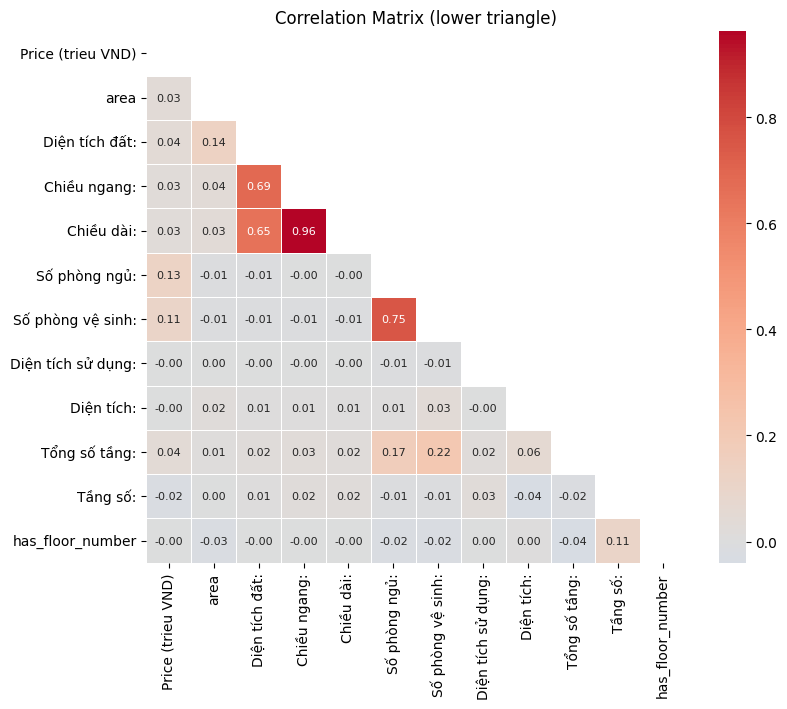


Top correlations với Price (trieu VND)
Số phòng ngủ:         0.126998
Số phòng vệ sinh:     0.111720
Diện tích đất:        0.039277
Tổng số tầng:         0.038892
area                  0.034587
Chiều ngang:          0.026768
Chiều dài:            0.025265
Tầng số:              0.020656
Diện tích sử dụng:    0.001474
Diện tích:            0.000771
Name: Price (trieu VND), dtype: float64


In [21]:
corr_cols = [TARGET] + [c for c in numeric_cols if c != TARGET]
corr_df   = df[corr_cols].dropna(how="all")

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(max(8, len(corr_cols) * 0.7), max(6, len(corr_cols) * 0.6)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Correlation Matrix (lower triangle)", fontsize=12)
plt.tight_layout()
plt.show()

# Top features tương quan với giá
print("\nTop correlations với", TARGET)
print(corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(10))

## 9. Feature Importance sơ bộ (Random Forest)

Dùng Random Forest nhanh để xem feature nào ảnh hưởng nhiều nhất đến giá — **chưa tune, chỉ để định hướng Preprocessing.**


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28944\3151210069.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns


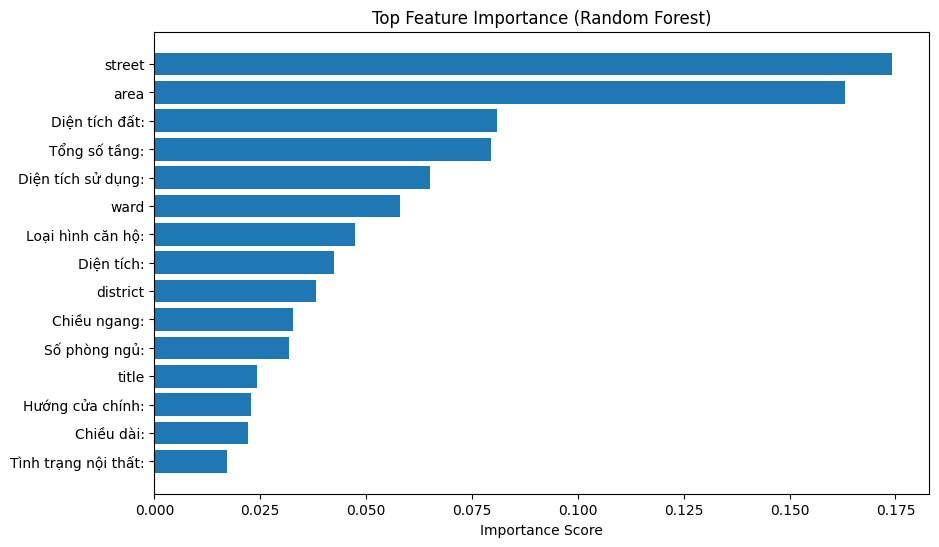

,Feature,Importance
22,street,0.174287
1,area,0.163135
2,Diện tích đất:,0.080900
17,Tổng số tầng:,0.079474
13,Diện tích sử dụng:,0.064973
23,ward,0.057891
16,Loại hình căn hộ:,0.047306
15,Diện tích:,0.042458
24,district,0.038092
7,Chiều ngang:,0.032779


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

TARGET = "Price (trieu VND)"

# Copy dataset
df_model = df.copy()

# Encode categorical columns
cat_cols = df_model.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# X và y
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

# Feature importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Top 15 feature
top_features = importance_df.head(15)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Feature Importance (Random Forest)")
plt.xlabel("Importance Score")

plt.show()

# Display table
importance_df.head(15)

Nhận xét:
- Street là feature có chỉ số importance lên price nhiều nhất
- Tình trạng nôi thấn ảnh hưởng lên price thấp nhất.

Tuy nhiên, khi phân tích các feature có unique thì street cao nhất. dễ gây overfit vậy thì lý do tại sao?

Bởi vì feature street có unique cao quá nên dẫn đến khiến cho model bị overfit. Vì thế dẫn đến việc model tưởng nhầm freature đó sẽ ảnh hướng lớn đến model.